# Curve Construction and Bootstrapping

Curve construction turns market quotes into discount factors, zero rates, and forward rates. These curves are then used for valuation, risk, stress testing, and scenario analysis.

Abbreviations used in this notebook:

- **DF**: Discount Factor, present value of one unit of currency received in the future.
- **ZC**: Zero-Coupon, an instrument with one payment at maturity.
- **OIS**: Overnight Indexed Swap, often used for collateralized discount curves.
- **YTM**: Yield to Maturity.
- **bps**: Basis Points, where 100 bps equals 1 percentage point.

## 1. Intuition

A yield curve is not just a line on a chart. In pricing systems, it is usually a set of discount factors and rates built from observable market instruments. Bootstrapping means solving the curve step by step: first solve the shortest maturity, then use that result to solve the next maturity, and continue outward along the curve.

Typical curve construction workflow:

1. Select market instruments, such as deposits, bills, futures, swaps, or bonds.
2. Clean and validate the quotes.
3. Convert quotes into discount factors or zero rates.
4. Interpolate between quoted maturities.
5. Derive forward rates and risk measures.
6. Publish the validated curve to pricing and risk systems.

In real banks, curve construction can be much more complex because different curves may be needed for discounting, forwarding, collateral currency, credit spreads, inflation, or cross-currency basis.

## 2. Mathematics

**Discount factor from a zero rate:**

$$
DF_t = \frac{1}{(1 + z_t)^t}
$$

Where:

- $DF_t$ = discount factor for maturity $t$
- $z_t$ = annual zero rate for maturity $t$
- $t$ = maturity in years

**Zero rate from a discount factor:**

$$
z_t = DF_t^{-1/t} - 1
$$

Where:

- $z_t$ = annual zero rate for maturity $t$
- $DF_t$ = discount factor for maturity $t$
- $t$ = maturity in years

**Par bond pricing equation:**

$$
P = \sum_{i=1}^{N} C_i \times DF_i + FV \times DF_N
$$

Where:

- $P$ = bond price
- $C_i$ = coupon cash flow at period $i$
- $DF_i$ = discount factor for period $i$
- $FV$ = face value repaid at maturity
- $N$ = final cash-flow period

**Bootstrapped final discount factor:**

$$
DF_N = \frac{P - \sum_{i=1}^{N-1} C_i \times DF_i}{FV + C_N}
$$

Where:

- $DF_N$ = discount factor solved for the final maturity
- $P$ = observed market price
- $C_i$ = coupon cash flow before maturity
- $DF_i$ = previously solved discount factors
- $FV + C_N$ = final principal plus final coupon

**Forward rate between two maturities:**

$$
f_{t_1,t_2} = \left(\frac{DF_{t_1}}{DF_{t_2}}\right)^{1/(t_2 - t_1)} - 1
$$

Where:

- $f_{t_1,t_2}$ = implied annual forward rate from $t_1$ to $t_2$
- $DF_{t_1}$ = discount factor at earlier maturity
- $DF_{t_2}$ = discount factor at later maturity
- $t_2 - t_1$ = length of the forward period in years


## 3. Implementation

We will build a simplified annual curve from zero-coupon and coupon bond quotes. The example is intentionally small so the bootstrapping logic is visible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.6f}".format

In [2]:
market_quotes = pd.DataFrame({
    "maturity_years": [1, 2, 3, 4, 5],
    "coupon_rate": [0.000, 0.025, 0.030, 0.035, 0.040],
    "price": [98.000, 99.200, 100.100, 101.000, 101.800],
    "face_value": [100.0, 100.0, 100.0, 100.0, 100.0],
})

market_quotes

,maturity_years,coupon_rate,price,face_value
0,1,0.000000,98.000000,100.000000
1,2,0.025000,99.200000,100.000000
2,3,0.030000,100.100000,100.000000
3,4,0.035000,101.000000,100.000000
4,5,0.040000,101.800000,100.000000


The 1-year instrument is a zero-coupon instrument, so its discount factor is solved directly from price divided by face value. Later coupon instruments use already solved earlier discount factors to solve the next maturity.

In [3]:
discount_factors = {}
bootstrap_rows = []

for row in market_quotes.itertuples(index=False):
    maturity = int(row.maturity_years)
    coupon = row.face_value * row.coupon_rate
    price = row.price

    if coupon == 0:
        discount_factor = price / row.face_value
        present_value_of_prior_coupons = 0.0
    else:
        present_value_of_prior_coupons = sum(
            coupon * discount_factors[period]
            for period in range(1, maturity)
        )
        discount_factor = (price - present_value_of_prior_coupons) / (row.face_value + coupon)

    discount_factors[maturity] = discount_factor
    zero_rate = discount_factor ** (-1 / maturity) - 1

    bootstrap_rows.append({
        "maturity_years": maturity,
        "price": price,
        "coupon_rate": row.coupon_rate,
        "pv_prior_coupons": present_value_of_prior_coupons,
        "discount_factor": discount_factor,
        "zero_rate": zero_rate,
    })

curve = pd.DataFrame(bootstrap_rows)
curve

,maturity_years,price,coupon_rate,pv_prior_coupons,discount_factor,zero_rate
0,1,98.000000,0.000000,0.000000,0.980000,0.020408
1,2,99.200000,0.025000,2.450000,0.943902,0.029287
2,3,100.100000,0.030000,5.771707,0.915809,0.029750
3,4,101.000000,0.035000,9.938989,0.879817,0.032528
4,5,101.800000,0.040000,14.878111,0.835787,0.036528


Forward rates are implied by the discount factors. They are not separate market observations in this example; they are rates that make adjacent discount factors internally consistent.

In [4]:
forward_rows = []

for start, end in zip(curve["maturity_years"].iloc[:-1], curve["maturity_years"].iloc[1:]):
    start_df = curve.loc[curve["maturity_years"] == start, "discount_factor"].iloc[0]
    end_df = curve.loc[curve["maturity_years"] == end, "discount_factor"].iloc[0]
    forward_rate = (start_df / end_df) ** (1 / (end - start)) - 1
    forward_rows.append({
        "forward_period": f"{int(start)}Y-{int(end)}Y",
        "forward_rate": forward_rate,
    })

forwards = pd.DataFrame(forward_rows)
forwards

,forward_period,forward_rate
0,1Y-2Y,0.038243
1,2Y-3Y,0.030676
2,3Y-4Y,0.040909
3,4Y-5Y,0.052680


## 4. Interpolation

Risk systems often need rates at maturities that are not directly quoted. Interpolation fills the gaps. This example uses linear interpolation on zero rates; production systems may use more specialized methods depending on the desk, currency, instrument, and regulatory requirements.

In [5]:
target_maturities = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0])
interpolated_zero_rates = np.interp(
    target_maturities,
    curve["maturity_years"],
    curve["zero_rate"],
)
interpolated_discount_factors = 1 / (1 + interpolated_zero_rates) ** target_maturities

interpolated_curve = pd.DataFrame({
    "maturity_years": target_maturities,
    "zero_rate": interpolated_zero_rates,
    "discount_factor": interpolated_discount_factors,
})

interpolated_curve

,maturity_years,zero_rate,discount_factor
0,1.000000,0.020408,0.980000
1,1.500000,0.024848,0.963854
2,2.000000,0.029287,0.943902
3,2.500000,0.029518,0.929854
4,3.000000,0.029750,0.915809
5,4.000000,0.032528,0.879817
6,5.000000,0.036528,0.835787


## 5. Visualization

A constructed curve is usually inspected visually before publication. Analysts look for jumps, humps, stale quotes, and inconsistent forward rates.

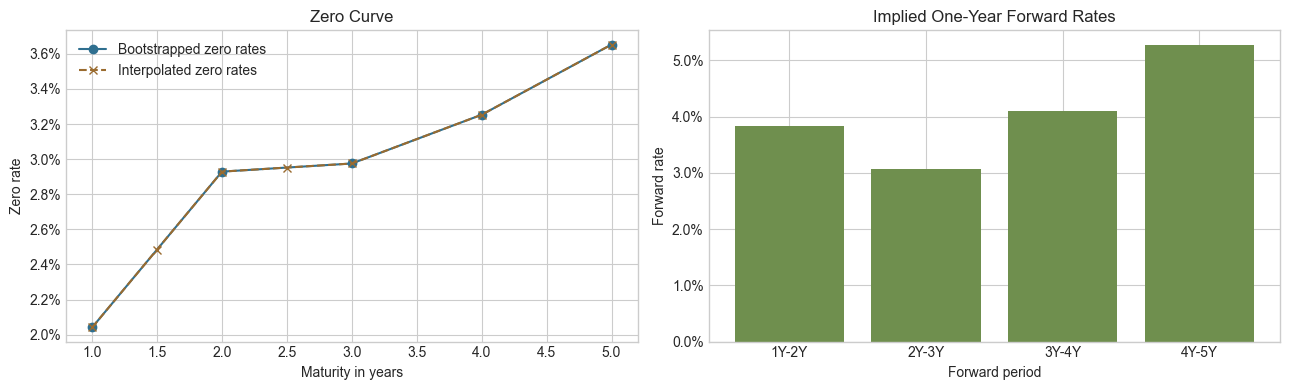

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(curve["maturity_years"], curve["zero_rate"], marker="o", label="Bootstrapped zero rates", color="#2f6f8f")
axes[0].plot(interpolated_curve["maturity_years"], interpolated_curve["zero_rate"], marker="x", linestyle="--", label="Interpolated zero rates", color="#9a6b2f")
axes[0].set_title("Zero Curve")
axes[0].set_xlabel("Maturity in years")
axes[0].set_ylabel("Zero rate")
axes[0].yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
axes[0].legend()

axes[1].bar(forwards["forward_period"], forwards["forward_rate"], color="#6f8f4e")
axes[1].set_title("Implied One-Year Forward Rates")
axes[1].set_xlabel("Forward period")
axes[1].set_ylabel("Forward rate")
axes[1].yaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")

plt.tight_layout()
plt.show()

## 6. Curve Shocks and Risk

Risk systems use constructed curves to estimate sensitivities. A simple parallel curve shock increases every zero rate by the same amount. Production systems also use key-rate shocks, twists, steepeners, flatteners, and historical scenarios.

In [7]:
cash_flows = pd.DataFrame({
    "maturity_years": [1, 2, 3, 4, 5],
    "cash_flow": [4, 4, 4, 4, 104],
})

base_rates = np.interp(cash_flows["maturity_years"], curve["maturity_years"], curve["zero_rate"])
base_dfs = 1 / (1 + base_rates) ** cash_flows["maturity_years"]
base_value = np.sum(cash_flows["cash_flow"] * base_dfs)

shock = 0.01
shocked_rates = base_rates + shock
shocked_dfs = 1 / (1 + shocked_rates) ** cash_flows["maturity_years"]
shocked_value = np.sum(cash_flows["cash_flow"] * shocked_dfs)

risk_summary = pd.DataFrame({
    "metric": [
        "Base value",
        "Value after +100 bps shock",
        "Price change",
        "Price change percent",
    ],
    "value": [
        f"{base_value:,.2f}",
        f"{shocked_value:,.2f}",
        f"{shocked_value - base_value:,.2f}",
        f"{(shocked_value / base_value - 1):.2%}",
    ],
})

risk_summary

,metric,value
0,Base value,101.80
1,Value after +100 bps shock,97.38
2,Price change,-4.42
3,Price change percent,-4.34%


## 7. Application

Curve construction supports pricing and risk across fixed income, derivatives, treasury, asset-liability management, and valuation. The details matter: instrument selection, quote quality, interpolation method, compounding convention, day-count convention, collateral assumptions, and curve governance can all change valuation and sensitivities.

## 8. Reflection

- Bootstrapping solves discount factors step by step from market quotes.
- Zero rates, discount factors, and forward rates are different views of the same curve information.
- Interpolation fills missing maturities but introduces modeling choices.
- Curve shocks translate rate movements into valuation changes.
- Production curve construction requires validation, governance, and consistent publication to risk systems.

Questions to answer after running the notebook:

1. Why can the first discount factor be solved directly from a zero-coupon quote?
2. Why does bootstrapping use previously solved discount factors?
3. What is the difference between a zero rate and a forward rate?
4. Why can interpolation methodology matter for valuation?
5. How does a parallel rate shock affect the value of fixed cash flows?